# IMDB Movie Review Sentiment Analysis

## Week 1 - Live Pakistan NLP Internship

### Objective
Build a machine learning model that classifies movie reviews as **Positive** or **Negative** using Natural Language Processing (NLP) techniques.

## Step 1: Import Required Libraries

In this step, we import the necessary Python libraries for data handling and analysis.

In [3]:
import pandas as pd

## Step 2: Load the Dataset

The IMDB dataset contains 50,000 movie reviews along with their sentiment labels (positive or negative).

In [4]:
df =pd.read_csv("data/IMDB Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Step 3: Explore Dataset Information

Let's examine the dataset structure, column names, and data types.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## Step 4: Analyze Sentiment Distribution

Check how many reviews are labeled as positive and negative.

In [6]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Step 5: Inspect Raw Movie Reviews

Let's look at a few reviews before applying any preprocessing.

In [7]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [8]:
df['review'][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [9]:
df['review'][2]

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [10]:
import sys
!python -m pip install BeautifulSoup4

## Step 6: Text Preprocessing

We will remove HTML tags, convert text to lowercase, and remove punctuation.

In [11]:
import re
from bs4 import BeautifulSoup

In [12]:
def clean_text(text):

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


In [13]:
sample_review = df['review'][0]

print("Original Review:\n")
print(sample_review)

print("\n" + "="*50 + "\n")

print("Cleaned Review:\n")
print(clean_text(sample_review))

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

## Step 7: Tokenization

Tokenization is the process of splitting text into individual words called tokens.

In [14]:
sample_review = clean_text(df['review'][0])

tokens = sample_review.split()

print(tokens)

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'youll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'methe', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', 'trust', 'me', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', 'sex', 'or', 'violence', 'its', 'is', 'hardcore', 'in', 'the', 'classic', 'use', 'of', 'the', 'wordit', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'it', 'focuses', 'mainly', 'on', 'emerald', 'city', 'an', 'experimental', 'section', 'of', 'the', 'prison', 'where', 'all', 'the', 'cells', 'have', 'glass

## Step 8: Download Stopwords

NLTK (Natural Language Toolkit) provides a collection of common English stopwords. These words are frequently used in sentences but usually do not carry significant sentiment information.

Examples:
- the
- is
- am
- are
- was
- were
- and
- of
- to

We will download the stopwords corpus and use it for text preprocessing.

In [15]:
import sys
!python -m pip install nltk

In [16]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ForestaSupport\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print(list(stop_words)[:20])

['at', 'didn', 'did', 'than', "he'll", 'up', 'myself', "it's", 'are', "she'd", "weren't", "hadn't", 'shan', 'which', 't', 'her', 'itself', 'shouldn', 'them', 'is']


## Step 9: Stopword Removal

Stopwords are common words that usually do not contribute much to sentiment prediction.

In [18]:
tokens = sample_review.split()

filtered_words = [
    word
    for word in tokens
    if word not in stop_words
]

print(filtered_words)

['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordit', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'awayi', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'wouldnt', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstream'

## Step 10: Lemmatization

Lemmatization converts words into their meaningful root forms while preserving their actual meaning.

Examples:

- studies → study
- cars → car
- movies → movie
- running → run

This helps reduce vocabulary size and allows similar words to be treated as the same feature during model training.

In [19]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ForestaSupport\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [21]:
lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_words
]

print(lemmatized_words)

['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordit', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslim', 'gangsta', 'latino', 'christian', 'italian', 'irish', 'moreso', 'scuffle', 'death', 'stare', 'dodgy', 'dealing', 'shady', 'agreement', 'never', 'far', 'awayi', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'go', 'show', 'wouldnt', 'dare', 'forget', 'pretty', 'picture', 'painted', 'mainstream', 'audience', 'forget', 

## Step 11: Create a Complete Preprocessing Function

Combine all preprocessing steps into a single function and apply it to the entire dataset.

In [22]:
def preprocess_text(text):

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [23]:
sample_review = df['review'][0]

processed_review = preprocess_text(sample_review)

print(processed_review)

one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned prison bitc

## Step 12: Apply Preprocessing to the Entire Dataset

In [24]:
df['clean_review'] = df['review'].apply(preprocess_text)

In [25]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


## Step 13: Encode Sentiment Labels

Convert sentiment labels into numerical values for machine learning.

In [26]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df['sentiment'].head()

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

## Step 14: TF-IDF Vectorization

Machine learning models cannot work directly with text data.

TF-IDF (Term Frequency - Inverse Document Frequency) converts text into numerical features while giving more importance to informative words and less importance to very common words.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['clean_review'])

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3895069 stored elements and shape (50000, 5000)>

## Step 15: Define Features and Target Variable

Separate the input features (X) and target labels (y).

In [29]:
y = df['sentiment']

print(X.shape)
print(y.shape)

(50000, 5000)
(50000,)


In [30]:
y = df['sentiment']

print(y.head())

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64


## Step 16: Split the Dataset

Split the dataset into training and testing sets.

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)
y_train shape: (40000,)
y_test shape: (10000,)


In [34]:
import sys
!python.exe -m pip install --upgrade pip

## Step 17: Train Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [37]:
lr_predictions = lr_model.predict(X_test)

## Step 18: Evaluate Logistic Regression Model

Evaluate the performance of the Logistic Regression model using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [39]:
accuracy = accuracy_score(y_test, lr_predictions)
precision = precision_score(y_test, lr_predictions)
recall = recall_score(y_test, lr_predictions)
f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8847
Precision: 0.8755315036722072
Recall   : 0.8989878944234967
F1 Score : 0.8871046705179673


In [40]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [41]:
cm = confusion_matrix(y_test, lr_predictions)

print(cm)

[[4317  644]
 [ 509 4530]]


In [42]:
import sys 
!python -m pip install seaborn

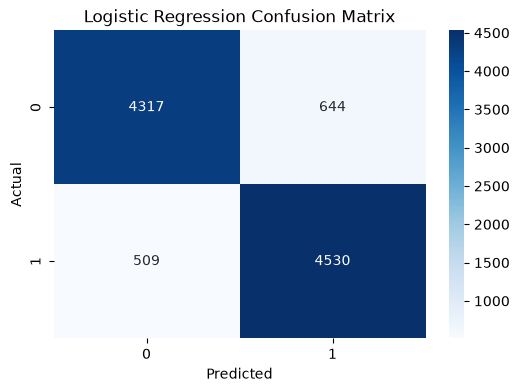

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 19: Train Multinomial Naive Bayes Model

Train a second classification model and compare its performance with Logistic Regression.

In [44]:
from sklearn.naive_bayes import MultinomialNB

In [45]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [46]:
print(nb_predictions[:10])

[0 1 0 1 0 1 1 0 0 0]


In [47]:
accuracy_nb = accuracy_score(y_test, nb_predictions)
precision_nb = precision_score(y_test, nb_predictions)
recall_nb = recall_score(y_test, nb_predictions)
f1_nb = f1_score(y_test, nb_predictions)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Accuracy : 0.8492
Precision: 0.8474709702814407
Recall   : 0.8545346298868823
F1 Score : 0.8509881422924901


## Step 20: Evaluate Multinomial Naive Bayes Model

Evaluate the performance of the Multinomial Naive Bayes model using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [48]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [49]:
cm_nb = confusion_matrix(y_test, nb_predictions)

print(cm_nb)

[[4186  775]
 [ 733 4306]]


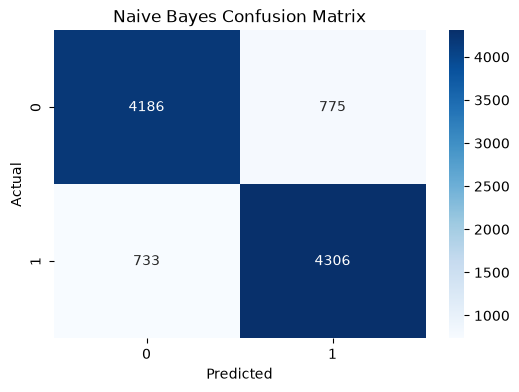

In [50]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 21: Model Comparison

Compare the performance of Logistic Regression and Multinomial Naive Bayes models using evaluation metrics.

In [51]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, accuracy_nb],
    "Precision": [precision, precision_nb],
    "Recall": [recall, recall_nb],
    "F1 Score": [f1, f1_nb]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8847,0.875532,0.898988,0.887105
1,Naive Bayes,0.8492,0.847471,0.854535,0.850988


## Step 22: Test the Model on Custom Reviews

Test the trained model on custom movie reviews and observe the predicted sentiment.

In [52]:
custom_reviews = [
    "This movie was absolutely amazing and I loved every moment of it.",
    "The film was boring, slow, and a complete waste of time.",
    "The acting was decent but the story was not very interesting."
]

In [53]:
clean_custom_reviews = [
    preprocess_text(review)
    for review in custom_reviews
]

In [54]:
custom_tfidf = tfidf.transform(clean_custom_reviews)

predictions = lr_model.predict(custom_tfidf)

In [55]:
for review, prediction in zip(custom_reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("-" * 60)

Review: This movie was absolutely amazing and I loved every moment of it.
Prediction: Positive
------------------------------------------------------------
Review: The film was boring, slow, and a complete waste of time.
Prediction: Negative
------------------------------------------------------------
Review: The acting was decent but the story was not very interesting.
Prediction: Negative
------------------------------------------------------------


## Step 23: Project Summary

In this project, Natural Language Processing (NLP) techniques were applied to classify movie reviews as positive or negative.

The dataset was cleaned using text preprocessing techniques such as HTML tag removal, lowercasing, punctuation removal, stopword removal, tokenization, and lemmatization.

TF-IDF vectorization was used to convert text into numerical features.

Two machine learning models, Logistic Regression and Multinomial Naive Bayes, were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

The results demonstrated that machine learning can effectively identify sentiment in movie reviews and automate sentiment classification tasks.

In [56]:
accuracy_nb = accuracy_score(y_test, nb_predictions)
precision_nb = precision_score(y_test, nb_predictions)
recall_nb = recall_score(y_test, nb_predictions)
f1_nb = f1_score(y_test, nb_predictions)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Accuracy : 0.8492
Precision: 0.8474709702814407
Recall   : 0.8545346298868823
F1 Score : 0.8509881422924901
